In [7]:
import sys
import os

current_dir = os.getcwd()
module_path = os.path.join(current_dir, '..', 'external', 'SOTA-py', 'src')
module_path = os.path.normpath(module_path)

if module_path not in sys.path:
    sys.path.append(module_path)

new_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'external', 'SOTA-py', 'graph'))

if new_folder_path not in sys.path:
    sys.path.append(new_folder_path)

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra
from utilities import Utils
from Grid_network_and_Gamma_distribution import Matrix

src_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'src'))

if src_folder_path not in sys.path:
    sys.path.append(src_folder_path)

from R2L_train import GridNet, afGridNet, reachGridNet
from R2L_test import Test
from R2L_utilities import R2LTestFunctions

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl


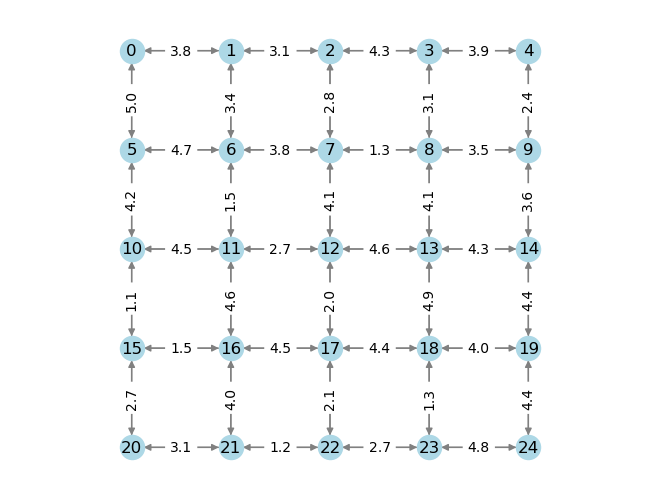

FileNotFoundError: [Errno 2] No such file or directory: './../instances/trained/grid_5x5_20000k500k-gn.pkl'

In [2]:
path_graph = "./../instances/graphs/5x5-1.pkl"

path_gn = "./../instances/trained/grid_5x5_20000k500k-gn.pkl"
path_af = "./../instances/trained/grid_5x5_20000k500k-af.pkl"
path_rh = "./../instances/trained/grid_5x5_20000k500k-rh.pkl"

R2LTestFunctions.gn_af_rh_path_comparison(path_graph, path_gn, path_af, path_rh, start_node = 10, 
                                          remaining_reward=25, dont_print=True, print_graph_path=True, print_graph_pruned=True)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0123s
data loaded correctly.
SOTA path: [0, 5, 6, 11, 12, 17, 22, 23, 24]


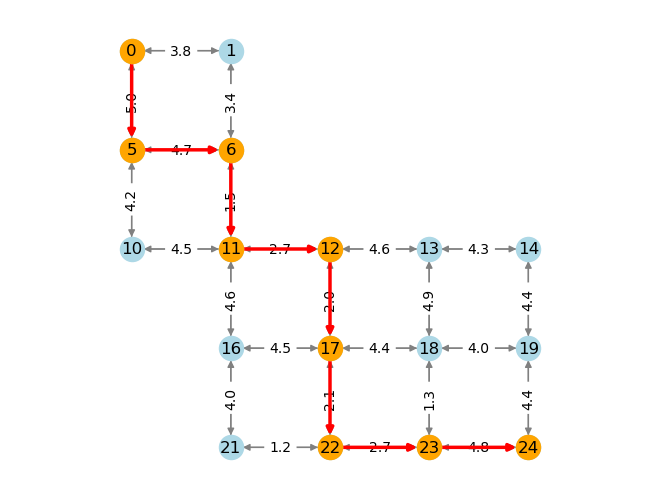

In [47]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_rh = "./../instances/trained/grid_5x5_test-rh.pkl"

graph = Utils.load_object(path_graph)
grid = reachGridNet(graph.get_adjacency_matrix(), graph.get_variance_matrix(), episode_number=500000, episode_lissage=50000)


test = Test(grid)
path = test.run(path_rh, start_node=0, remaining_reward=25, dont_print=True)

grid.get_graph().print_graph(path=path)



#R2LTestFunctions.path_run(path_graph, path_rh, grid_type="reach", start_node=0, remaining_reward = 25, dont_print=True,print_graph_path=True)

In [ ]:
path_graph = "./../instances/graphs/5x5-1.pkl"

R2LTestFunctions.train_run(path_graph, "reach", 0, 24, 100000, 25000, "./../instances/trained/grid_5x5_undefined.pkl")

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0134s
Episode =  10000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  1.7086044830079536
Episode =  20000 ----------  Error norm sup =  1.1358664450276309e-08 ----------  Error norm 1 =  1.0251156441502602e-10
step_nbr =  2.3686131386861313
Episode =  30000 ----------  Error norm sup =  0.013975610370381454 ----------  Error norm 1 =  0.00031539655729519357
step_nbr =  2.411873840445269
Episode =  40000 ----------  Error norm sup =  0.015413524629153737 ----------  Error norm 1 =  0.00034096514681039624
step_nbr =  2.379840196681008
Episode =  50000 ----------  Error norm sup =  0.01843001483863208 ----------  Error norm 1 =  0.0003436780333367793
step_nbr =  2.384661473936489
Episode =  60000 ----------  Error norm sup =  0.016360250361127253 ----------  Error norm 1 =  0.00034437100338459187
step_nbr =  2.4633375

In [8]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5-1_undefined-gn.pkl"
path_af = "./../instances/trained/grid_5x5-1_undefined-af.pkl"
path_rh = "./../instances/trained/grid_5x5-1_undefined-rh.pkl"

R2LTestFunctions.train_general_comparison(path_graph, 0, 24, 500000, 50000, path_gn, path_af, path_rh)

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
Episode =  50000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  2.8060769965001593
Episode =  100000 ----------  Error norm sup =  1.462065862739885e-06 ----------  Error norm 1 =  1.2071509051793381e-08
step_nbr =  2.999547033066586
Episode =  150000 ----------  Error norm sup =  0.062198343068991246 ----------  Error norm 1 =  0.00141604018487164
step_nbr =  3.0634405429330185
Episode =  200000 ----------  Error norm sup =  0.05740025558427362 ----------  Error norm 1 =  0.0014658900119582008
step_nbr =  3.0794022853794316
Episode =  250000 ----------  Error norm sup =  0.06280152801505035 ----------  Error norm 1 =  0.0015265221432714622
step_nbr =  3.125204460966543
Episode =  300000 ----------  Error norm sup =  0.06172684410869245 ----------  Error norm 1 =  0.0015087867265315526
step_nbr =  3.0538484050336554
Episode =  350000 ----------  Error norm sup =  0.05691383221

In [33]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5-1_undefined-gn.pkl"
path_af = "./../instances/trained/grid_5x5-1_undefined-af.pkl"
path_rh = "./../instances/trained/grid_5x5-1_undefined-rh.pkl"

R2LTestFunctions.train_general_comparison(path_graph, 0, 24, 2000000, 200000, path_gn, path_af, path_rh)

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
Episode =  200000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  3.0181376215407627
Episode =  400000 ----------  Error norm sup =  9.738740347187145e-05 ----------  Error norm 1 =  1.028913754024377e-06
step_nbr =  3.0587592835299255
Episode =  600000 ----------  Error norm sup =  0.206948032050939 ----------  Error norm 1 =  0.005879759256892312
step_nbr =  3.0727600943118185
Episode =  800000 ----------  Error norm sup =  0.1590376268915042 ----------  Error norm 1 =  0.006119613455559602
step_nbr =  3.0918311503520743
Episode =  1000000 ----------  Error norm sup =  0.2923227152988661 ----------  Error norm 1 =  0.00636521743936006
step_nbr =  3.0466737606868968
Episode =  1200000 ----------  Error norm sup =  0.19399151660236774 ----------  Error norm 1 =  0.006410679900854318
step_nbr =  3.040517335866428
Episode =  1400000 ----------  Error norm sup =  0.174913452742799

In [9]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/undefined.pkl"
path_af = "./../instances/trained/undefined.pkl"
path_rh = "./../instances/trained/undefined.pkl"

R2LTestFunctions.train_general_comparison(path_graph, 0, 24, 5000000, 500000, path_gn, path_af, path_rh)

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
Episode =  500000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  3.002689562428882
Episode =  1000000 ----------  Error norm sup =  0.0010716607207267041 ----------  Error norm 1 =  1.7073762388427126e-05
step_nbr =  3.020962335133869
Episode =  1500000 ----------  Error norm sup =  0.33757924645200765 ----------  Error norm 1 =  0.015057816237808629
step_nbr =  3.018109035455585
Episode =  2000000 ----------  Error norm sup =  0.3174295196142109 ----------  Error norm 1 =  0.016426573878904862
step_nbr =  3.029182736724788
Episode =  2500000 ----------  Error norm sup =  0.36410657091269855 ----------  Error norm 1 =  0.016958098588356917
step_nbr =  3.035286452549124
Episode =  3000000 ----------  Error norm sup =  0.254579270729112 ----------  Error norm 1 =  0.017516157935723933
step_nbr =  3.014955782262708
Episode =  3500000 ----------  Error norm sup =  0.72471571838537

========= STANDARD R2L ==========

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded correctly.
SOTA path: [0, 5, 6, 11, 12, 17, 18, 19, 24]
Probability Q-value: 3.493065004895331e-11


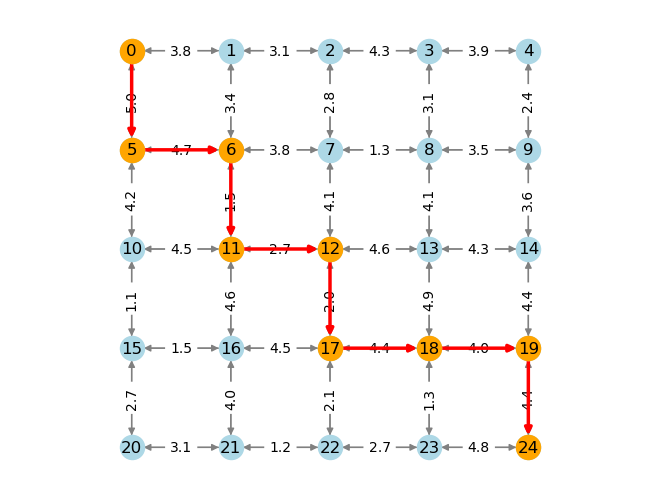


======== ARC-FLAGS R2L ========

Object loaded from ./../instances/graphs/5x5-1.pkl
Partitioning of the graph in 4 regions executed in 0.0030 seconds!
Arcflags computed!...
[ArcFlags] Pruned 9 edges for destination 24 (region 0).
Arcflags computed and graph pruned in 0.0100s
data loaded correctly.
SOTA path: [0, 1, 6, 11, 12, 17, 22, 23, 24]
Probability Q-value: 7.995032455900728e-12


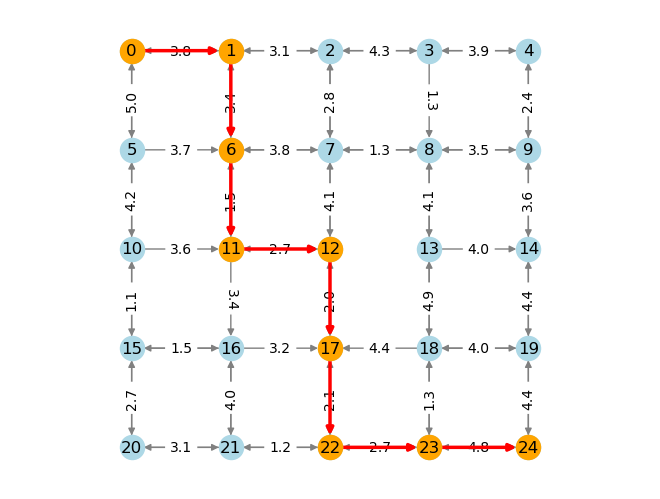


========== REACH R2L ==========

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0132s
data loaded correctly.
SOTA path: [0, 1, 6, 11, 16, 17, 18, 23, 24]
Probability Q-value: 9.825198040385715e-11


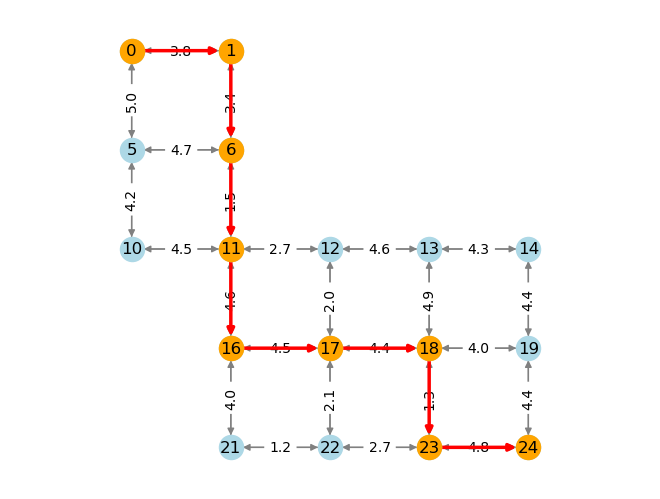

In [5]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_af = "./../instances/trained/grid_5x5-1_500k50k-af.pkl"
path_gn = "./../instances/trained/grid_5x5-1_500k50k-gn.pkl"
path_rh = "./../instances/trained/grid_5x5-1_500k50k-rh.pkl"

R2LTestFunctions.gn_af_rh_path_comparison(path_graph, path_gn, path_af, path_rh, 
                                          0, 29, dont_print=True, print_graph_path=True)

In [15]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_save = "./../instances/trained/grid_5x5-1_100k25k-erh-plus50.pkl"

R2LTestFunctions.train_run(path_graph, grid_type="embedded_reach",
                           episode_number=100000, episode_lissage=25000,
                           path_save = path_save)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Episode =  25000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  2.577277379733879
Episode =  50000 ----------  Error norm sup =  2.1103207185354033e-07 ----------  Error norm 1 =  1.3503661251742758e-09
step_nbr =  3.142265601892931
Episode =  75000 ----------  Error norm sup =  0.0290587935422095 ----------  Error norm 1 =  0.000711157837152673
step_nbr =  3.0125284738041
Episode =  100000 ----------  Error norm sup =  0.034123642803631796 ----------  Error norm 1 =  0.0007208905958907139
step_nbr =  3.123854566952409
Learning phase completed in 45.75 seconds
data saved


45.747071266174316

In [8]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_save = "./../instances/trained/grid_5x5-1_500k50k-erh-plus.pkl"

R2LTestFunctions.train_run(path_graph, grid_type="embedded_reach",
                           episode_number=500000, episode_lissage=50000,
                           path_save = path_save)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Episode =  50000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  2.746086105675147
Episode =  100000 ----------  Error norm sup =  8.673829026799473e-07 ----------  Error norm 1 =  1.1727096862114717e-08
step_nbr =  3.0139631610219846
Episode =  150000 ----------  Error norm sup =  0.05531703367687614 ----------  Error norm 1 =  0.0013984908647914102
step_nbr =  2.976857311320755
Episode =  200000 ----------  Error norm sup =  0.057882539000295274 ----------  Error norm 1 =  0.0014631645458294982
step_nbr =  3.060167775527914
Episode =  250000 ----------  Error norm sup =  0.08347028052171256 ----------  Error norm 1 =  0.0015295711769338096
step_nbr =  3.0510537251409913
Episode =  300000 ----------  Error norm sup =  0.051123913380121344 ----------  Error norm 1 =  0.0014862641103446474
step_nbr =  3.0463382546411344
Episode =  350000 ----------  Error norm sup =  0.

279.61289167404175